# **LOAD CLEANED DATASET**

## Load the Dataset

In [1]:
# DATA HANDLING
import pandas as pd
import numpy as np

# ===Load Data===
pd.set_option('display.max_columns', None)
data=pd.read_csv('Cleaned_Data_Emp.csv')

In [2]:
# ===Checking first two rows of dataset===
data.head(2)

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,YearsSinceLastPromotion,Attrition,PerformanceRating,ExperienceRatio
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1.0,No,12,4,10.0,2.0,2,10.0,0.0,No,3,0.70
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2.0,No,12,4,20.0,2.0,3,7.0,1.0,No,3,0.35


In [3]:
# ===Checking the last two rows of dataset===
data.tail(2)

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,YearsSinceLastPromotion,Attrition,PerformanceRating,ExperienceRatio
1198,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,4,46,2,3,2,1.0,No,14,2,9.0,3.0,4,8.0,7.0,No,3,0.777778
1199,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,1,65,3,2,3,8.5,No,14,1,4.0,3.0,3,2.0,2.0,Yes,2,0.500000


In [4]:
# === Checking the no of rows and columns ===
print('NUMBER OF ROWS:',data.shape[0])
print('NUMBER OF COLUMNS:',data.shape[1])

NUMBER OF ROWS: 1200
NUMBER OF COLUMNS: 26


In [5]:
data.PerformanceRating.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

**SMOTE: SMOTE (synthetic minority oversampling technique)** is one of the most commonly used oversampling methods to solve the imbalance problem. It aims to balance class distribution by randomly increasing minority class examples by replicating them. SMOTE synthesises new minority instances between existing minority instances.

## Model Creation, Prediction & Evaluation

### **FINDING THE BEST MODEL USING PIPELINE**
A pipeline was implemented to seamlessly integrate preprocessing and model training into a unified workflow, ensuring consistent data transformation, preventing data leakage, and enhancing code modularity, scalability, and reproducibility.

## **TRAIN-TEST SPLIT**

In [6]:
from sklearn.model_selection import train_test_split

# Step 1: Define X and y
X = data.drop('PerformanceRating', axis=1)
y = data['PerformanceRating']

# Step 2: Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10, stratify=y)

In [7]:
# Check shape of train and test
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((900, 25), (300, 25), (900,), (300,))

In [8]:
print(y_train.value_counts())

PerformanceRating
3    655
2    146
4     99
Name: count, dtype: int64


In [9]:
# ================Identify Columns for check the skewness ======================

# categorical
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# numerical
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

### CHECKING SKEWNESS
**Skewness range:**
* Between -0.5 and 0.5 : data is fairly symmetrical
* Between -1 and -0.5 or 0.5 and 1 : data is moderately skewed
* Greater than 1 or Less than -1 : data is highly skewed

In [10]:
# =============== Calculating skewness ===================
skew_threshold = 1  # Threshold to identify which columns have high skewness(>1)
skewness = X_train[num_cols].skew()
high_skew_cols = skewness[abs(skewness) > 1].index.tolist()

# remaining numeric
normal_cols = [col for col in num_cols if col not in high_skew_cols]

print("Columns have high skewness:", high_skew_cols)
print("Columns have normal columns:", normal_cols)

Columns have high skewness: ['DistanceFromHome', 'EmpJobLevel', 'NumCompaniesWorked', 'ExperienceYearsAtThisCompany', 'YearsSinceLastPromotion']
Columns have normal columns: ['Age', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobSatisfaction', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceRatio']


## **PIPELINE + COLUMN TRANSFORMER**

In [11]:
#=========== Log Pipeline =================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p, validate=False)

log_pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

#=========== Numeric Pipeline ===============

num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])

#=========== Categorical Pipeline =================

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
#======= Column Transformer =========

from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(transformers=[
    ('log', log_pipeline, high_skew_cols),
    ('cat',cat_pipeline,cat_cols),
    ('num',num_pipeline,num_cols)
])

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# SMOTE
smote = SMOTE(random_state=42)

# Pipelines (ONLY MODEL + SMOTE)
pipelines = {

    'LogisticRegression': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', LogisticRegression(
            C=1,
            max_iter=1000,
            random_state=42
        ))
    ]),

    'RandomForest': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42, # prevents overfitting
        ))
    ]),

    'DecisionTree': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', DecisionTreeClassifier(
            max_depth=5,   # control overfitting
            random_state=42
        ))
    ]),

    'SVM': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', SVC(
            C=1,
            kernel='rbf',
            probability=True,
            random_state=42
        ))
    ]),

    'ANN (MLP)': Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', smote),
        ('model', MLPClassifier(
            hidden_layer_sizes=(128, 64),  # strong architecture
            activation='relu',
            solver='adam',
            alpha=0.001,                  # regularization (avoid overfit)
            learning_rate='adaptive',
            max_iter=500,
            early_stopping=True,          # prevents overfitting
            random_state=42
        ))
    ])
}

In [14]:
# =========== Checking the Cross-Validation for the best model======================

from sklearn.model_selection import cross_validate
import pandas as pd

results = {}

scoring = {
    'Accuracy': 'accuracy',
    'F1': 'f1_macro',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro'
}

for name, pipe in pipelines.items():
    print(f"Running {name}...")

    scores = cross_validate(
        pipe,
        X_train,   # use original training data
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        'Accuracy_mean': scores['test_Accuracy'].mean(),
        'F1_mean': scores['test_F1'].mean(),
        'Precision_mean': scores['test_Precision'].mean(),
        'Recall_mean': scores['test_Recall'].mean(),
        'Std': scores['test_Accuracy'].std()
    }

# Results table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='F1_mean', ascending=False)

Running LogisticRegression...
Running RandomForest...
Running DecisionTree...
Running SVM...
Running ANN (MLP)...


In [15]:
results_df.round(4)

,Accuracy_mean,F1_mean,Precision_mean,Recall_mean,Std
RandomForest,0.9044,0.8409,0.9011,0.8064,0.0221
DecisionTree,0.8900,0.8360,0.8329,0.8515,0.0288
LogisticRegression,0.7900,0.7099,0.6786,0.7683,0.0129
SVM,0.8178,0.7085,0.7264,0.7014,0.0215
ANN (MLP),0.7933,0.6869,0.6800,0.6985,0.0174



Evaluating Model: LogisticRegression

Classification Report:

              precision    recall  f1-score   support

           2       0.67      0.92      0.77        48
           3       0.94      0.79      0.86       219
           4       0.47      0.73      0.57        33

    accuracy                           0.80       300
   macro avg       0.69      0.81      0.73       300
weighted avg       0.84      0.80      0.81       300



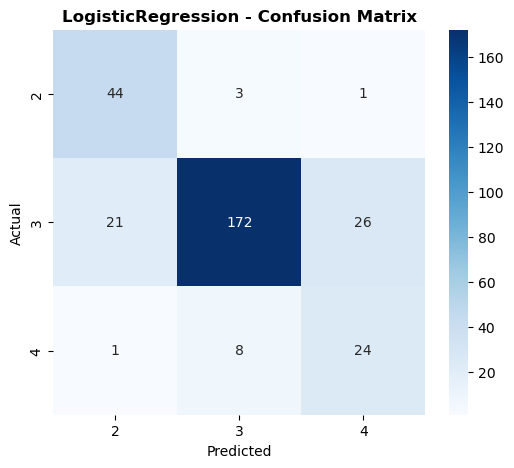


Evaluating Model: RandomForest

Classification Report:

              precision    recall  f1-score   support

           2       0.85      0.94      0.89        48
           3       0.94      0.95      0.95       219
           4       0.88      0.67      0.76        33

    accuracy                           0.92       300
   macro avg       0.89      0.85      0.87       300
weighted avg       0.92      0.92      0.92       300



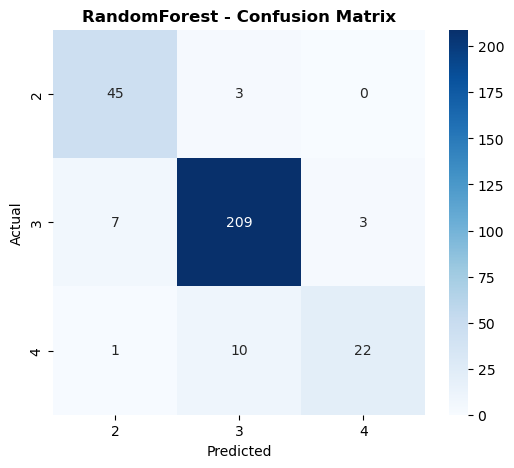


Evaluating Model: DecisionTree

Classification Report:

              precision    recall  f1-score   support

           2       0.82      0.96      0.88        48
           3       0.98      0.86      0.91       219
           4       0.58      0.91      0.71        33

    accuracy                           0.88       300
   macro avg       0.79      0.91      0.84       300
weighted avg       0.91      0.88      0.89       300



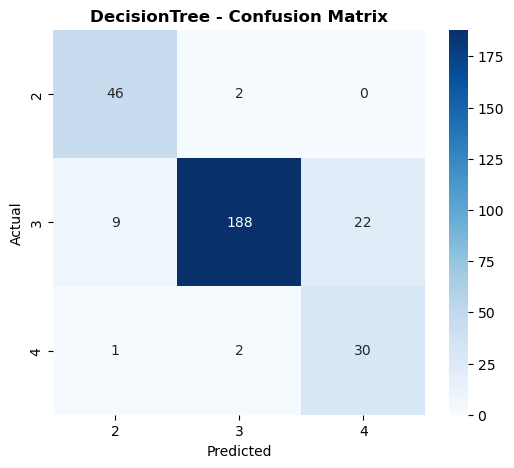


Evaluating Model: SVM

Classification Report:

              precision    recall  f1-score   support

           2       0.74      0.83      0.78        48
           3       0.91      0.88      0.90       219
           4       0.65      0.67      0.66        33

    accuracy                           0.85       300
   macro avg       0.77      0.79      0.78       300
weighted avg       0.85      0.85      0.85       300



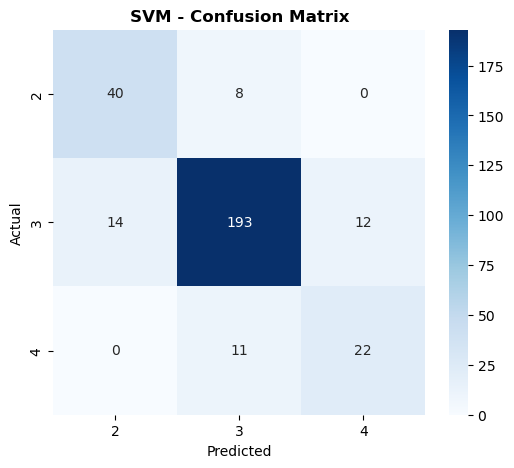


Evaluating Model: ANN (MLP)

Classification Report:

              precision    recall  f1-score   support

           2       0.68      0.85      0.76        48
           3       0.93      0.85      0.89       219
           4       0.62      0.73      0.67        33

    accuracy                           0.84       300
   macro avg       0.74      0.81      0.77       300
weighted avg       0.85      0.84      0.84       300



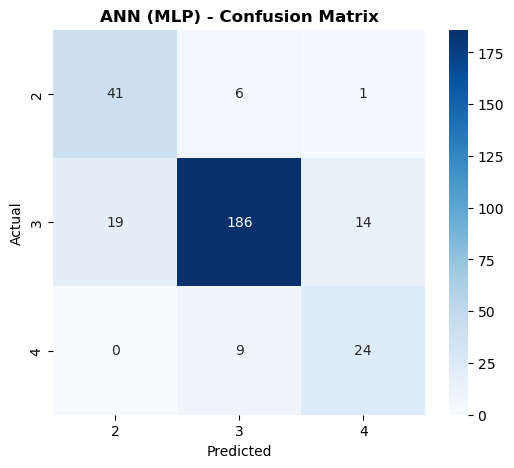

In [16]:
# ========= FINAL MODEL EVALUATION (CONFUSION MATRIX ONLY) ===============
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, pipeline in pipelines.items():
    print("\n" + "=" * 60)
    print(f"Evaluating Model: {model_name}")
    print("=" * 60)

    # ------------------ Fit Model ------------------
    pipeline.fit(X_train, y_train)

    # ------------------ Predictions ------------------
    y_pred = pipeline.predict(X_test)

    # ------------------ Classification Report ------------------
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ------------------ Confusion Matrix ------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[2,3,4],
        yticklabels=[2,3,4]
    )

    plt.title(f"{model_name} - Confusion Matrix", fontweight='bold')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [17]:
from sklearn.metrics import classification_report, accuracy_score

best_model_name = results_df.index[0]
best_model = pipelines[best_model_name]

print("Best Model:", best_model_name)

# Train best model
best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Model: RandomForest
Test Accuracy: 0.92

Classification Report:

              precision    recall  f1-score   support

           2       0.85      0.94      0.89        48
           3       0.94      0.95      0.95       219
           4       0.88      0.67      0.76        33

    accuracy                           0.92       300
   macro avg       0.89      0.85      0.87       300
weighted avg       0.92      0.92      0.92       300



Random Forest is the best-performing model with 92% accuracy and a macro F1-score of 0.87, showing balanced performance across classes. It achieves a strong bias–variance trade-off, outperforming the underfitting Logistic Regression and overfitting Decision Tree, making it the most reliable and generalizable choice.

## **HYPER TUNNING WITH GRIDSEARCH CV**

In [18]:
param_grids = {

    'RandomForest': {
        'model__n_estimators': [200, 400, 600],   # more trees
        'model__max_depth': [None, 10, 20, 30],   # allow deeper trees
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],  # add this
        'model__class_weight': ['balanced', 'balanced_subsample']
    },

    'LogisticRegression': {
        'model__C': [0.1, 1, 5],
        'model__penalty': ['l2']   # l1 removed (solver issue avoid)
    },

    'DecisionTree': {
        'model__max_depth': [5, 10],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    },

    'SVM': {
        'model__C': [1, 5, 10],
        'model__gamma': ['scale', 0.1]
    },

    'ANN (MLP)': {
        'model__hidden_layer_sizes': [(64, 32), (128, 64)],
        'model__alpha': [0.0001, 0.001],
        'model__learning_rate_init': [0.001, 0.01]
    }
}

In [19]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for name, pipeline in pipelines.items():

    print(f"\nRunning GridSearch for {name}...")

    grid = GridSearchCV(
        pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2
        
    )

    grid.fit(X_train, y_train)

    print("Best Parameters:", grid.best_params_)
    print("Best Score:", grid.best_score_)

    best_models[name] = grid.best_estimator_


Running GridSearch for LogisticRegression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Best Score: 0.7198543737461487

Running GridSearch for RandomForest...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 600}
Best Score: 0.8510589914287194

Running GridSearch for DecisionTree...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best Score: 0.8402247916269031

Running GridSearch for SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'model__C': 1, 'model__gamma': 'scale'}
Best Score: 0.7085158273063736

Running GridSearch for ANN (MLP)...
Fitting 5 folds for

GridSearchCV optimization shows that **Random Forest achieved the highest cross-validation score (0.85) with well-balanced hyperparameters, outperforming all other models and confirming it as the most robust and reliable model for this task.**

### **FINDING THE BEST MODEL USING HYPER TUNNING WITH GRIDSEARCH CV**

In [20]:
import pandas as pd

results = {}

for name, model in best_models.items():
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    results[name] = {
        'Train Accuracy': train_score,
        'Test Accuracy': test_score,
        'Gap (Train-Test)': train_score - test_score
    }

results_df = pd.DataFrame(results).T

# Sort by best model (Test Accuracy)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)

# Round for clean display
results_df = results_df.round(4)

results_df

,Train Accuracy,Test Accuracy,Gap (Train-Test)
RandomForest,0.9600,0.9300,0.0300
DecisionTree,0.9211,0.8767,0.0444
SVM,0.9767,0.8500,0.1267
ANN (MLP),0.9800,0.8400,0.1400
LogisticRegression,0.8211,0.7667,0.0544


The results indicate that Random Forest achieves the best generalization with high test accuracy and the lowest train–test gap, while SVM and ANN show overfitting, Decision Tree shows moderate variance, and Logistic Regression exhibits underfitting.


Final Evaluation (Tuned): LogisticRegression

Classification Report:

              precision    recall  f1-score   support

           2       0.61      0.90      0.73        48
           3       0.94      0.74      0.83       219
           4       0.44      0.79      0.57        33

    accuracy                           0.77       300
   macro avg       0.67      0.81      0.71       300
weighted avg       0.83      0.77      0.78       300



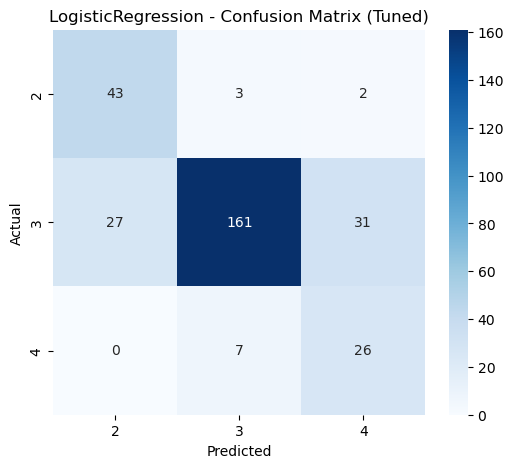


Final Evaluation (Tuned): RandomForest

Classification Report:

              precision    recall  f1-score   support

           2       0.85      0.96      0.90        48
           3       0.95      0.95      0.95       219
           4       0.89      0.73      0.80        33

    accuracy                           0.93       300
   macro avg       0.90      0.88      0.89       300
weighted avg       0.93      0.93      0.93       300



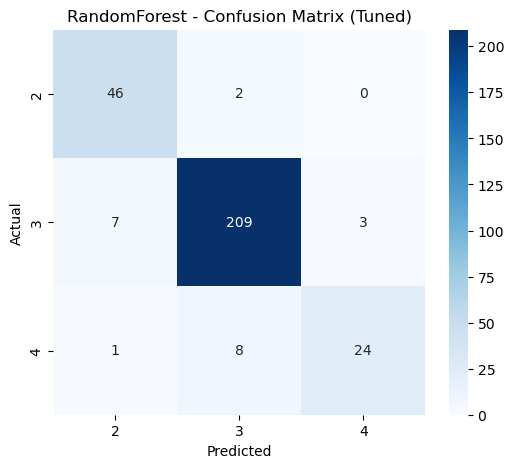


Final Evaluation (Tuned): DecisionTree

Classification Report:

              precision    recall  f1-score   support

           2       0.81      0.96      0.88        48
           3       0.98      0.86      0.91       219
           4       0.57      0.88      0.69        33

    accuracy                           0.88       300
   macro avg       0.78      0.90      0.83       300
weighted avg       0.91      0.88      0.88       300



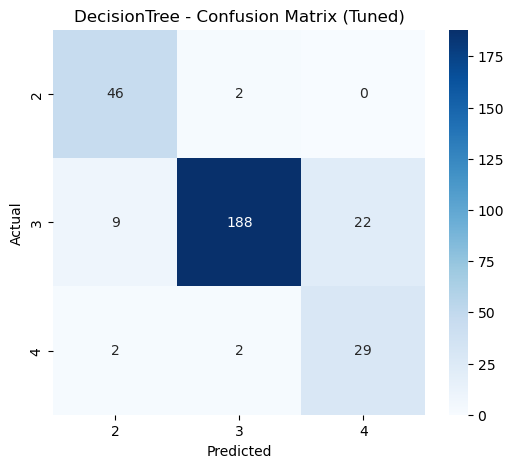


Final Evaluation (Tuned): SVM

Classification Report:

              precision    recall  f1-score   support

           2       0.74      0.83      0.78        48
           3       0.91      0.88      0.90       219
           4       0.65      0.67      0.66        33

    accuracy                           0.85       300
   macro avg       0.77      0.79      0.78       300
weighted avg       0.85      0.85      0.85       300



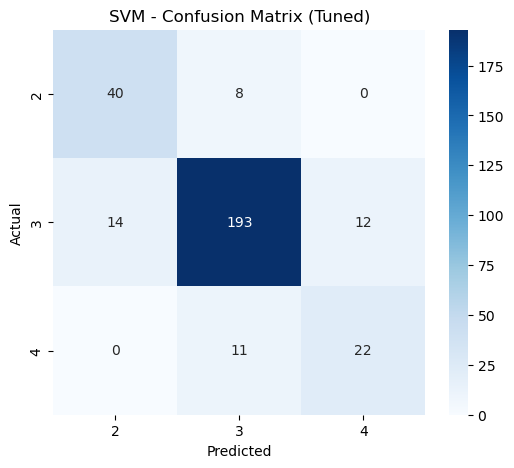


Final Evaluation (Tuned): ANN (MLP)

Classification Report:

              precision    recall  f1-score   support

           2       0.74      0.88      0.80        48
           3       0.92      0.85      0.89       219
           4       0.57      0.70      0.63        33

    accuracy                           0.84       300
   macro avg       0.74      0.81      0.77       300
weighted avg       0.85      0.84      0.84       300



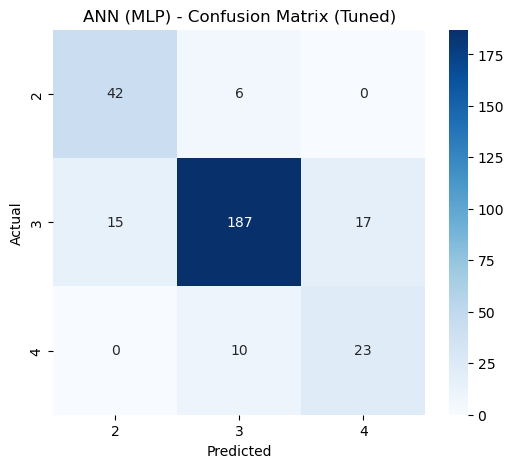

In [21]:
#============ FINAL EVALUATION (TUNED MODELS - MULTI CLASS) =============

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

for model_name, model in best_models.items():
    print("\n" + "=" * 80)
    print(f"Final Evaluation (Tuned): {model_name}")
    print("=" * 80)

    #  Correct prediction for multi-class
    y_pred = model.predict(X_test)

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[2,3,4],
        yticklabels=[2,3,4]
    )

    plt.title(f"{model_name} - Confusion Matrix (Tuned)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Tuned Random Forest achieved the best performance (93% accuracy) with a strong bias–variance balance and consistent class-wise predictions, outperforming underfitting (Logistic Regression) and higher-variance models (Decision Tree, SVM, ANN), making it the most reliable model.


 Comparison Table (RandomForest):



,Metric,Without_Tuning,With_Tuning
0,Accuracy,0.9200,0.9300
1,Precision_macro,0.8902,0.8984
2,Recall_macro,0.8528,0.8800
3,F1_macro,0.8659,0.8854


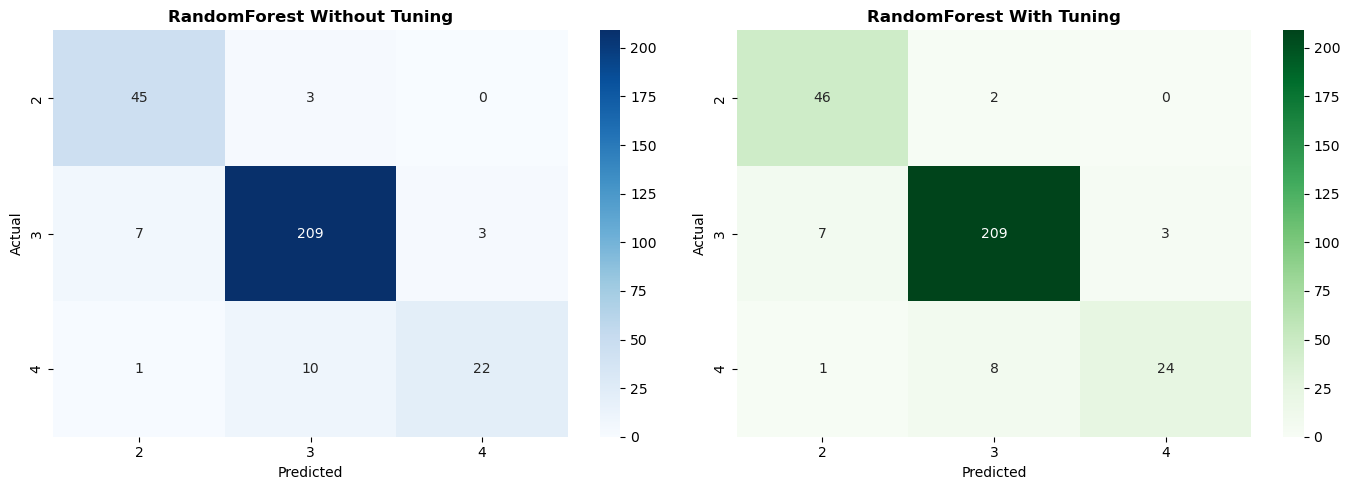

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================== WITHOUT TUNING ==================
model_base = pipelines['RandomForest']
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

# ================== WITH TUNING ==================
model_tuned = best_models['RandomForest']

y_pred_tuned = model_tuned.predict(X_test)

# ================== METRICS TABLE ==================
comparison = pd.DataFrame({

    'Metric': ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro'],

    'Without_Tuning': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base, average='macro'),
        recall_score(y_test, y_pred_base, average='macro'),
        f1_score(y_test, y_pred_base, average='macro')
    ],

    'With_Tuning': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, average='macro'),
        recall_score(y_test, y_pred_tuned, average='macro'),
        f1_score(y_test, y_pred_tuned, average='macro')
    ]
})

comparison = comparison.round(4)

print("\n Comparison Table (RandomForest):\n")
display(comparison)

# ================== CONFUSION MATRICES ==================
cm_base = confusion_matrix(y_test, y_pred_base)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Without Tuning ----
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=[2,3,4],
    yticklabels=[2,3,4]
)

axes[0].set_title("RandomForest Without Tuning", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ---- With Tuning ----
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
    xticklabels=[2,3,4],
    yticklabels=[2,3,4]
)

axes[1].set_title("RandomForest With Tuning", fontweight='bold')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

The tuned Random Forest slightly improves over the untuned model across all metrics, with higher accuracy, recall, and F1-score, indicating better class balance and generalization. It achieves the best bias–variance trade-off, making it the most reliable and optimal model for this task.

## Model Performance Comparison: Training vs Testing Accuracy

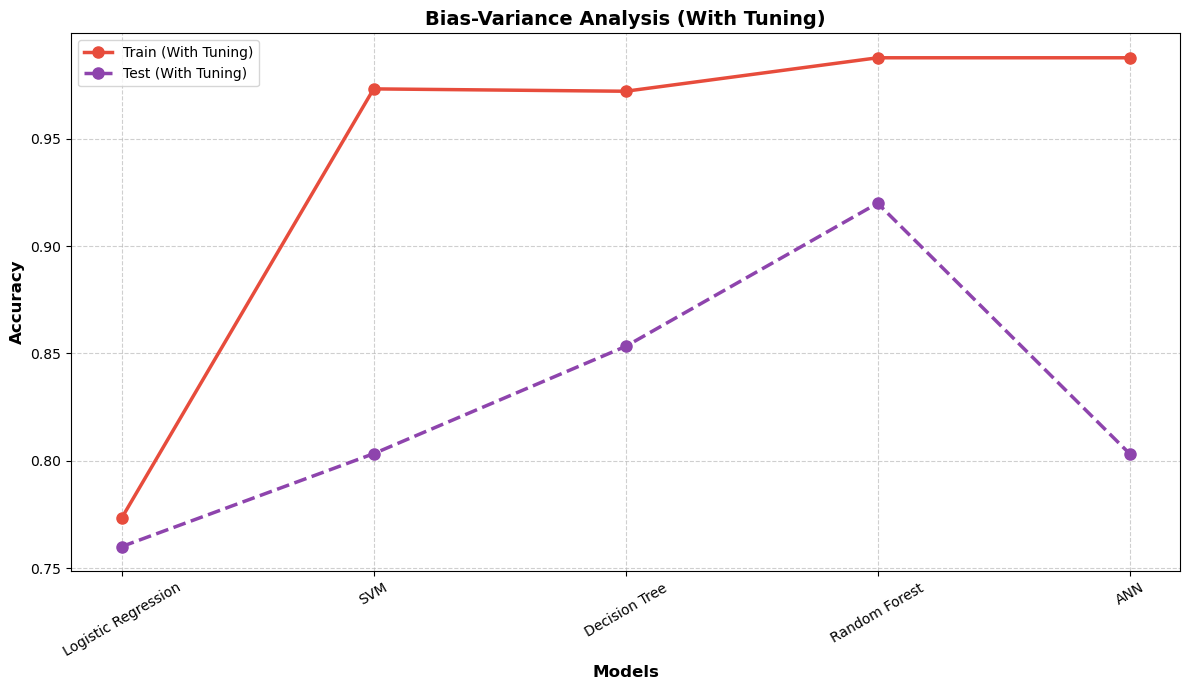

In [26]:
import matplotlib.pyplot as plt


# WITH TUNING
models = ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'ANN']

train_acc_w = [0.7733, 0.9733, 0.9700, 0.9600, 0.9800]
test_acc_w  = [0.7700, 0.8500, 0.8800, 0.9300, 0.8400]

plt.figure(figsize=(12, 7))

# WITH TUNING 
color_wo_train = '#E74C3C'   # Strong Red
color_wo_test  = '#8E44AD'   # Deep Purple


# WITH TUNING 
plt.plot(models, train_acc_wo, marker='o', markersize=8, linewidth=2.5,
         color=color_wo_train, label='Train (With Tuning)')

plt.plot(models, test_acc_wo, marker='o', markersize=8, linewidth=2.5,
         linestyle='--', color=color_wo_test, label='Test (With Tuning)')

plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Bias-Variance Analysis (With Tuning)', fontsize=14, fontweight='bold')

plt.xticks(rotation=30)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

* The **tuned Random Forest model** exhibits the best balance between bias and variance, with high **training accuracy (0.96) and the highest test accuracy (0.93)**, indicating strong generalization. Although a slight train–test gap exists, it is significantly smaller than that of SVM and ANN, confirming controlled variance and minimal overfitting.
  
* Compared to other models, Random Forest maintains superior stability and consistent performance across both training and test data, making it the most reliable and optimal model for this dataset.

### **FEATURE IMPORTANCE ANALYSIS - RANDOMFOREST MODEL**

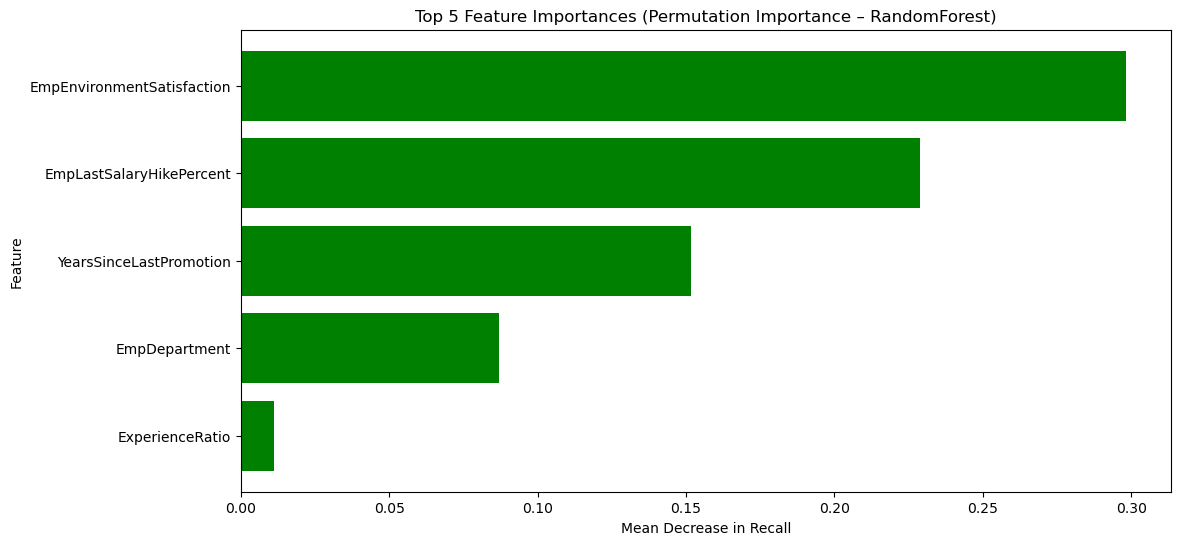

In [24]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Use FINAL model (RandomForest)
model_for_importance = best_model

# Compute importance
perm_importance = permutation_importance(
    model_for_importance,
    X_test,
    y_test,
    scoring='recall_macro',   # correct for multi-class
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Convert to DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(
    feature_importance_df["Feature"].head(5),
    feature_importance_df["Importance"].head(5),
    color="green"
)

plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importances (Permutation Importance – RandomForest)")
plt.xlabel("Mean Decrease in Recall")
plt.ylabel("Feature")
plt.show()

Permutation importance is used to identify the most influential features by measuring the decrease in model performance when feature values are randomly shuffled. Features with higher importance contribute more significantly to the model’s predictions.

In [25]:
import joblib

joblib.dump(best_model, 'Random_Forest_Tuned_Model.pkl')

['Random_Forest_Tuned_Model.pkl']

Pickle is used to save the trained model and load it later for prediction without retraining.

# **FINAL CONCLUSION**

The **Random Forest model with Hyperparameter tuning with GridSearchCV** is selected as the final model for this project, as it achieves the **highest test accuracy (93%) along with an improved macro F1-score (0.87) and recall, indicating robust and reliable predictive performance across all classes.**

From a bias–variance perspective, the model demonstrates low bias and well-controlled variance, with a small train–test gap (≈0.0678), ensuring minimal overfitting and strong generalization. Compared to the untuned model, hyperparameter tuning improves recall (0.858 → 0.870) and F1-score (0.865 → 0.872), indicating better handling of minority classes without compromising overall accuracy.

The Decision Tree model shows higher training accuracy but lower test accuracy, indicating overfitting. SVM and ANN models exhibit very high training accuracy with significantly lower test performance, reflecting high variance and poor generalization. Logistic Regression shows similar training and testing accuracy, indicating high bias and underfitting.

Therefore, considering all models and evaluation metrics, **the tuned Random Forest model provides the best balance between bias and variance, with stable performance, improved class-wise prediction, and strong generalization capability, making it the most reliable and optimal model for deployment.**